In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy

import caustics
from caustics import Module, forward, Param
from caustics import utils

import sncosmo

from torch.nn.functional import conv2d, avg_pool2d
import torch
from torch import pi
from torch import where
from torch import Tensor

import h5py
import os


mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'serif'

In [24]:
def sncosmo_lightcurve(times, band, zero_point, z_source):
    model = sncosmo.Model(source='salt2')
    model.set(z=z_source, t0=50, x1=0.1, c=-0.1)
    model.set_source_peakabsmag(-19.3, 'bessellb', 'ab')  # Calculate the correct x0 for the corresponding redshift
    x0 = model.get('x0')
    
    fluxes = model.bandflux(band, times, zp=zero_point, zpsys='ab')    # detector counts
    return times, fluxes

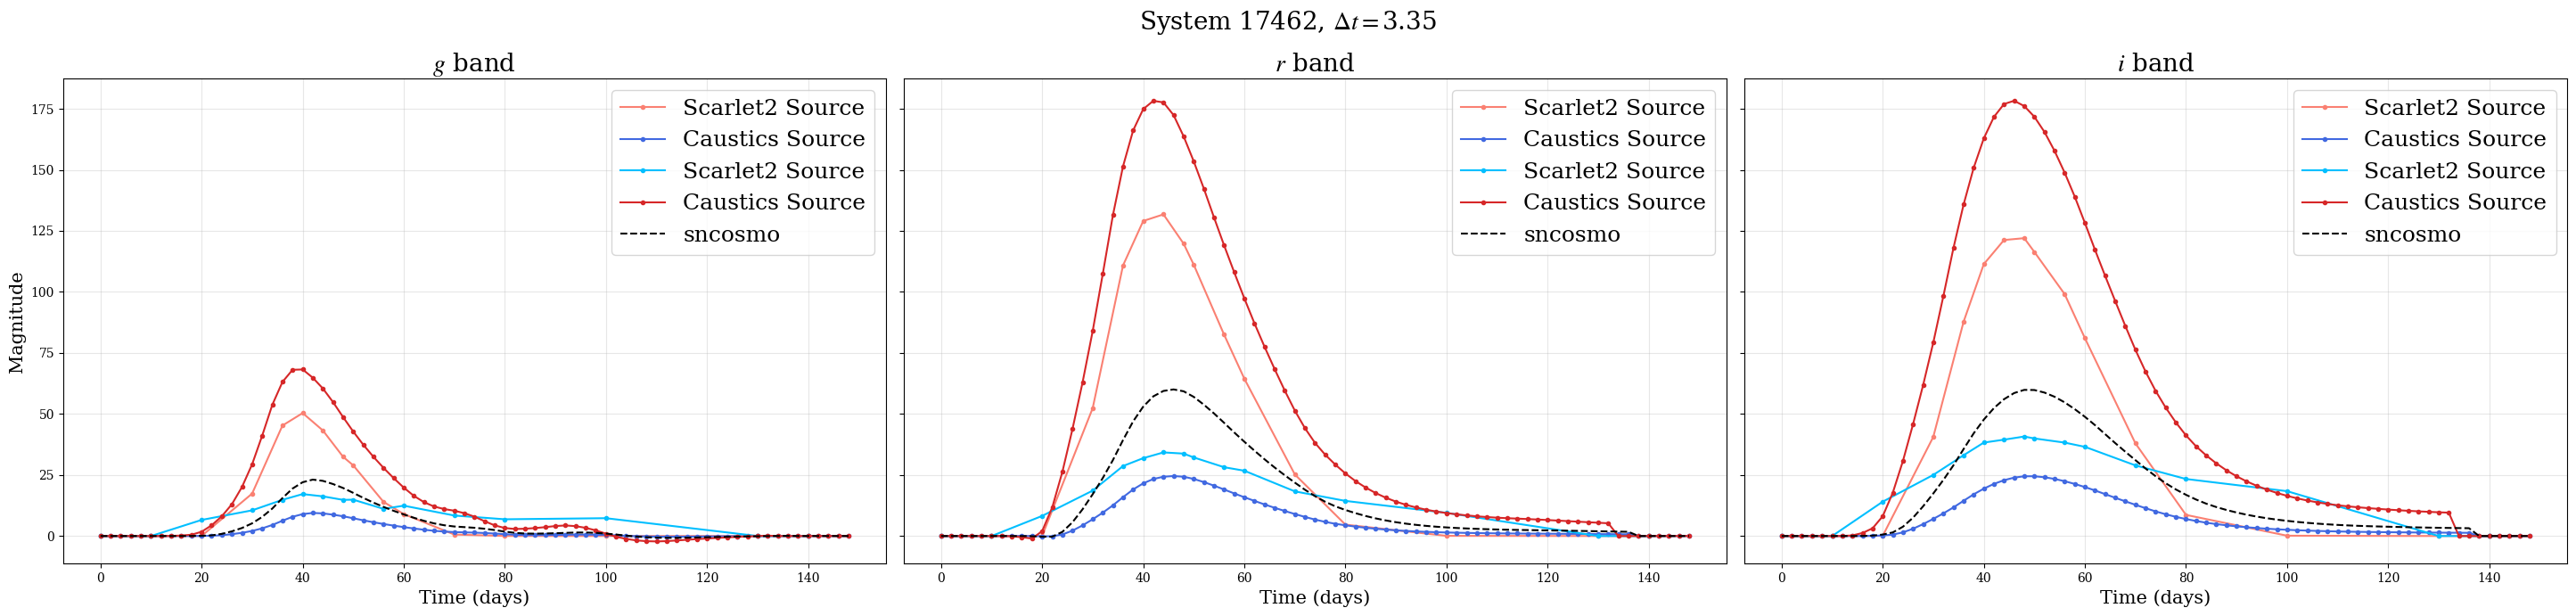

In [30]:
img_index = 17462 #72358 #17462 #96679

if img_index == 96679:
    z_source = 0.6728093548400655    #96679
    sc_times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130]
elif img_index == 17462:
    z_source = 0.7200284346083838    #17462
    sc_times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]
elif img_index == 72358:
    z_source = 0.7344597447566079    #72358
    sc_times = [0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140]
else:
    print('z_source?')
    
caustics_times = np.arange(0, 150, 2) 


caustics_version = '_04_03_26'
scarlet_version = '_v2'
td = '3.35'


bands = ['lsstg', 'lsstr', 'lssti']
band_names = [r'$g$', r'$r$', r'$i$']
zero_points = [28.30, 28.13, 27.79]
all_fluxes = []

sncosmo_light_curves = []
for i, band in enumerate(bands):
    _, sncosmo_lc = sncosmo_lightcurve(caustics_times, band, zero_points[i], z_source)
    sncosmo_light_curves.append(sncosmo_lc)

    
import pickle
with open('fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_'+str(img_index)+scarlet_version+'.pkl', "rb") as sc_f:
    scarelt_fluxes = pickle.load(sc_f)  #[band][epoch][image]

with open('fluxes_files/caustics_flux/caustics_fluxes_'+str(img_index)+caustics_version+'.pkl', "rb") as caustics_f:
    caustics_fluxes = pickle.load(caustics_f)  #[band][epoch][image]


fig, axes = plt.subplots(1, 3, figsize=(29, 7), sharey=True)

for band_indx, ax in enumerate(axes):  # number of bands
    caustics_colors = ['royalblue', 'tab:red']
    n_caustics_epochs = len(caustics_fluxes[band_indx])
    sc_colors = ['salmon', 'deepskyblue']
    n_sc_epochs = len(scarelt_fluxes[band_indx])
    n_sc_images = len(scarelt_fluxes[band_indx][0])

    for img_indx in range(n_sc_images):  # number of images 
        sc_flux = np.array([scarelt_fluxes[band_indx][t][img_indx] for t in range(n_sc_epochs)])
        ax.plot(sc_times, sc_flux, marker='o', markersize=3, label='Scarlet2 Source', color = sc_colors[img_indx])

        caustics_flux = np.array([caustics_fluxes[band_indx][t][img_indx] for t in range(n_caustics_epochs)])
        ax.plot(caustics_times, caustics_flux, marker='o', markersize=3, label='Caustics Source', color = caustics_colors[img_indx])

    
    ax.plot(caustics_times, sncosmo_light_curves[band_indx], label='sncosmo', color='black', linestyle='--')

    ax.set_title(band_names[band_indx] + ' band', fontsize = 20)
    ax.set_xlabel('Time (days)', fontsize = 15)
    ax.legend(loc='upper right', fontsize=18)
    ax.grid(alpha=0.3)



axes[0].set_ylabel('Magnitude', fontsize = 15)
fig.suptitle('System '+str(img_index) + r', $\Delta t = $' + td, fontsize = 20)
# fig.legend(loc='upper right')
plt.tight_layout()
plt.savefig(str(img_index)+'_light_curves_flux'+scarlet_version+caustics_version+'.png')
plt.show()


# Magnitude version

/tmp/ipykernel_3640872/1430350633.py:4: RuntimeWarning: divide by zero encountered in log10
  sncosmo_mags = zero_points[b] - 2.5 * np.log10(sncosmo_lc)
/tmp/ipykernel_3640872/1430350633.py:4: RuntimeWarning: invalid value encountered in log10
  sncosmo_mags = zero_points[b] - 2.5 * np.log10(sncosmo_lc)
/tmp/ipykernel_3640872/1430350633.py:20: RuntimeWarning: divide by zero encountered in log10
  sc_mags = zero_points[band_indx] - 2.5 * np.log10(sc_flux)
/tmp/ipykernel_3640872/1430350633.py:27: RuntimeWarning: divide by zero encountered in log10
  caustics_mags = zero_points[band_indx] - 2.5 * np.log10(caustics_flux)
/tmp/ipykernel_3640872/1430350633.py:27: RuntimeWarning: invalid value encountered in log10
  caustics_mags = zero_points[band_indx] - 2.5 * np.log10(caustics_flux)


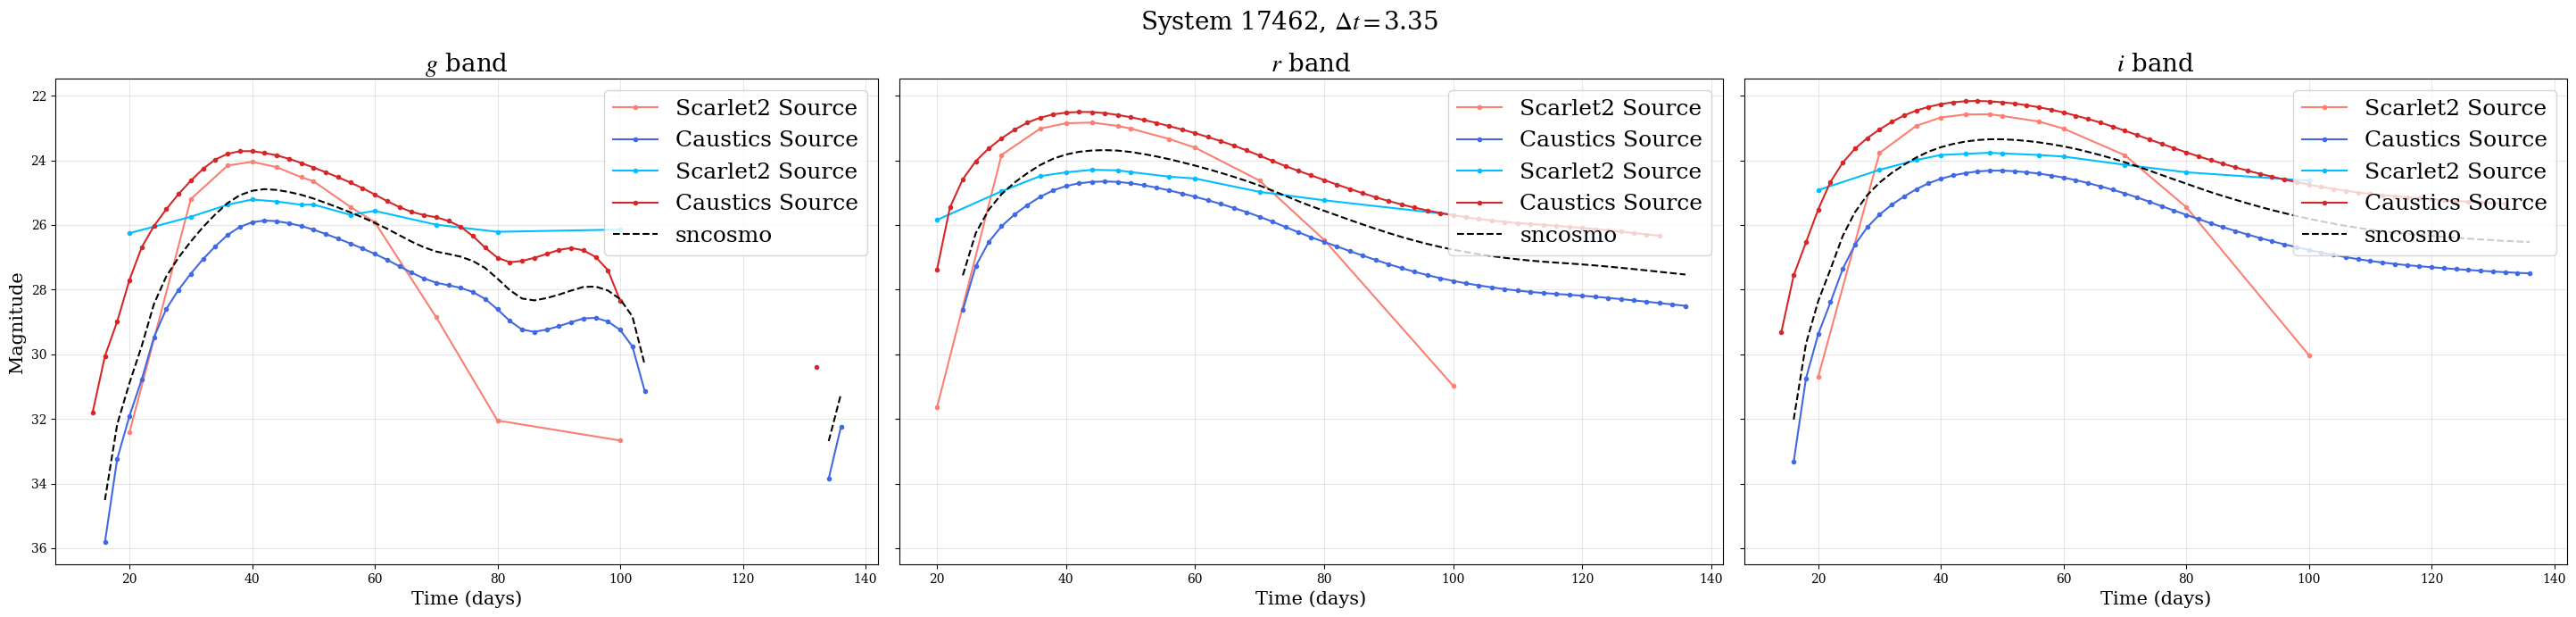

In [32]:
sncosmo_mags_lc = []
for b, band in enumerate(bands):
    _, sncosmo_lc = sncosmo_lightcurve(caustics_times, band, zero_points[b], z_source)
    sncosmo_mags = zero_points[b] - 2.5 * np.log10(sncosmo_lc)
    sncosmo_mags_lc.append(sncosmo_mags)



fig, axes = plt.subplots(1, 3, figsize=(29, 7), sharey=True)

for band_indx, ax in enumerate(axes):  # number of bands
    caustics_colors = ['royalblue', 'tab:red']
    n_caustics_epochs = len(caustics_fluxes[band_indx])
    sc_colors = ['salmon', 'deepskyblue']
    n_sc_epochs = len(scarelt_fluxes[band_indx])
    n_sc_images = len(scarelt_fluxes[band_indx][0])

    for img_indx in range(n_sc_images):  # number of images 
        sc_flux = np.array([scarelt_fluxes[band_indx][t][img_indx] for t in range(n_sc_epochs)])
        sc_mags = zero_points[band_indx] - 2.5 * np.log10(sc_flux)
        # if img_indx == 0:
        #     print(sc_mags)
        sc_mags[sc_mags > 35] = -np.inf
        ax.plot(sc_times, sc_mags, marker='o', markersize=3, label='Scarlet2 Source', color = sc_colors[img_indx])

        caustics_flux = np.array([caustics_fluxes[band_indx][t][img_indx] for t in range(n_caustics_epochs)])
        caustics_mags = zero_points[band_indx] - 2.5 * np.log10(caustics_flux)
        ax.plot(caustics_times, caustics_mags, marker='o', markersize=3, label='Caustics Source', color = caustics_colors[img_indx])

    
    ax.plot(caustics_times, sncosmo_mags_lc[band_indx], label='sncosmo', color='black', linestyle='--')

    ax.set_title(band_names[band_indx] + ' band', fontsize = 20)
    ax.set_xlabel('Time (days)', fontsize = 15)
    ax.legend(loc='upper right', fontsize=18)
    ax.invert_yaxis()
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Magnitude', fontsize = 15)
fig.suptitle('System '+str(img_index) + r', $\Delta t = $' + td, fontsize = 20)
# fig.legend(loc='upper right')
plt.tight_layout()
plt.savefig(str(img_index)+'_light_curves_mags'+scarlet_version+caustics_version+'.png')
plt.show()
